In [167]:
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from collections import Counter
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import pickle

WINDOW_SIZE = 5
HIDDEN_DIM = 100
NUM_NEGATIVES = 5
START_LR = 0.025
LR_FACTOR = 0.0001
NUM_PRECOMPUTED_RANDOMS = 10_000_000
NUM_PRECOMPUTED_NEGATIVES = 10_000_000
MAX_GRAD = 5
NUM_EPOCHS = 1
DISCARDING_THRESHOLD = 1e-3
LOSS_SMOOTH_WINDOW = 100000

# Load Dataset

I will use WikiText-103, consisting of spans from Wikipedia. It contains 103 million word tokens.

In [ ]:
data = load_dataset("wikitext", "wikitext-103-raw-v1", split="train")

# Tokenize and Create Vocabulary

In [ ]:
# Convert text to lowercase, remove everything except letters, and tokenize with nltk
tokens = []
for text in tqdm(data["text"]):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens.extend(word_tokenize(text))
token_counts = Counter(tokens)

# Remove very rare tokens and create token to id mappings
token_counts = {token: count for token, count in token_counts.items() if count >= 5}
tokens = set(token_counts.keys())
token_to_id = {token: idx for idx, token in enumerate(tokens)}
id_to_token = {idx: token for token, idx in token_to_id.items()}

  0%|          | 0/1801350 [00:00<?, ?it/s]

In [86]:
def encode(sequence):
    sequence = sequence.lower()
    sequence = re.sub(r'[^a-z\s]', '', sequence)
    encoded = []
    for token in word_tokenize(sequence):
        if token in token_to_id:
            encoded.append(token_to_id[token])
    return encoded

# Precompute Token Frequencies Distribution

The original paper used token frequencies to remove frequent tokens from texts and to sample negatives.
The negatives were sampled according to the following probabilities:

$$P_n(w) = \frac{f(w)^{3/4}}{\sum_{w' \in V} f(w')^{3/4}}$$

where $f(w)$ is the frequency of token $w$


In [ ]:
# Compute token frequencies for subsampling
vocabulary_size = len(token_to_id)
token_freqs = np.array([token_counts[id_to_token[idx]] for idx in range(vocabulary_size)], dtype=np.float64)
token_freqs /= token_freqs.sum()

# For negative sampling, the original paper used token freqs to the power of 3/4
token_freqs_neg_sampling = token_freqs ** 0.75
token_freqs_neg_sampling /= token_freqs_neg_sampling.sum()

# Pre-tokenization with Subsampling of Most Frequent Tokens

Tokens where kept with the following probability:

$$P(w) = \sqrt{\frac{t}{f(w)}}$$

where $f(w)$ is the frequency of token $w$, and $t$ is a threshold. The original paper used $t=10^{-5}$, however I used $t=10^{-3}$ after empirically testing on several examples.


In [ ]:
# Precompute random numbers for faster execution
precomputed_randoms = np.random.random(size=NUM_PRECOMPUTED_RANDOMS)
keep_probs = np.sqrt(DISCARDING_THRESHOLD / token_freqs)

tokenized_dataset = []
step = 0
for text in tqdm(data["text"]):
    tokenized = encode(text)
    tokenized_subsampled = []
    # If precomputed random is smaller than keep probability, we keep the token
    for token in tokenized:
        if precomputed_randoms[step % NUM_PRECOMPUTED_RANDOMS] < keep_probs[token]:
            tokenized_subsampled.append(token)
        step += 1
    if len(tokenized_subsampled) > 1:
        tokenized_dataset.append(tokenized_subsampled)

  0%|          | 0/1801350 [00:00<?, ?it/s]

### Save tokenized dataset

In [ ]:
pickle.dump(tokenized_dataset, open("data/tokenized_wikitext_103.pkl", "wb"))

# Implement Gradient Computation

Please see the math derivations of gradients in the `math_derivations.pdf` file.

In [92]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def compute_target_gradients(target_score, hidden_vector):
    return (sigmoid(target_score) - 1) * hidden_vector


def compute_context_gradients(target_score, target_vector, negative_scores, negative_vectors, window_size):
    return 1 / window_size * ((sigmoid(target_score) - 1) * target_vector + 
                              np.sum(sigmoid(negative_scores)[np.newaxis, :] * negative_vectors, axis=1))
    
    
def compute_negative_gradients(negative_scores, hidden_vector):
    return sigmoid(negative_scores)[np.newaxis, :] * hidden_vector[:, np.newaxis]

# Implement Learning Rate Decay

The original approach used linear learning rate decay

In [116]:
def get_lr(step, total_steps, initial_lr=START_LR, lr_factor=LR_FACTOR):
    lr = initial_lr * (1 - step / total_steps)
    return max(lr, initial_lr * lr_factor)

# Implement Training Loop

First, I initialize model weights. The input embeddings is initialized with small random values. The output embeddings are initialized with zeros. This approach is used in the original implementation. During the first train iteration all tokens receive same scores, but gradients differ across tokens.

In [132]:
# Initialized weights
embedding_matrix = np.random.uniform(-0.5 / HIDDEN_DIM, 0.5 / HIDDEN_DIM, (vocabulary_size, HIDDEN_DIM))
output_matrix = np.zeros((HIDDEN_DIM, vocabulary_size))

# Precompute negatives
precomputed_negatives = np.random.choice(vocabulary_size, 
                                         size=(NUM_PRECOMPUTED_NEGATIVES, NUM_NEGATIVES), 
                                         p=token_freqs_neg_sampling)

# Precompute window sizes
precomputed_windows = np.random.randint(1, WINDOW_SIZE + 1, size=NUM_PRECOMPUTED_RANDOMS)

Second, the training loop itself

In [ ]:
total_steps = NUM_EPOCHS * sum(len(encoded) for encoded in tokenized_dataset)
losses = []
step = 0

for epoch in range(NUM_EPOCHS):
    for i, encoded in enumerate(tqdm(tokenized_dataset)):
        for j in range(len(encoded)):
            # Select window size
            window_size = precomputed_windows[step % len(precomputed_windows)]
            
            # Select target token
            target = encoded[j]
            target_vector = output_matrix[:, target]
            
            # Select context
            # Context size: 2 * WINDOW_SIZE
            # If the window goes beyond the text boundaries, clip it
            context = encoded[max(0, j - window_size):j] + encoded[j + 1:min(len(encoded), j + window_size + 1)]
            
            # Select negatives
            negatives = precomputed_negatives[step % len(precomputed_negatives)]
            
            # Take embeddings of all tokens from the context
            context_embeddings = embedding_matrix[context]
            
            # Average the context embeddings
            hidden_vector = np.mean(context_embeddings, axis=0)
            
            # Obtain negative vectors
            negative_vectors = output_matrix[:, negatives]
            
            # Compute scores for the target and negatives
            target_score = np.dot(hidden_vector, output_matrix[:, target])
            negative_scores = np.dot(hidden_vector, output_matrix[:, negatives])
                    
            # Compute loss
            loss = -np.log(sigmoid(target_score)) - np.sum(np.log(sigmoid(-negative_scores)))
            losses.append(loss)
            
            # Compute gradients
            target_gradients = compute_target_gradients(target_score, hidden_vector)
            context_gradients = compute_context_gradients(target_score, target_vector, negative_scores, negative_vectors, window_size)
            negative_gradients = compute_negative_gradients(negative_scores, hidden_vector)
            
            # Get current learning rate and update weights
            lr = get_lr(step, total_steps)
            output_matrix[:, target] -= lr * np.clip(target_gradients, -MAX_GRAD, MAX_GRAD)
            output_matrix[:, negatives] -= lr * np.clip(negative_gradients, -MAX_GRAD, MAX_GRAD)
            embedding_matrix[context] -= lr * np.clip(context_gradients, -MAX_GRAD, MAX_GRAD)
            
            step += 1

  0%|          | 0/1030003 [00:00<?, ?it/s]

# Plot Training Loss Curve

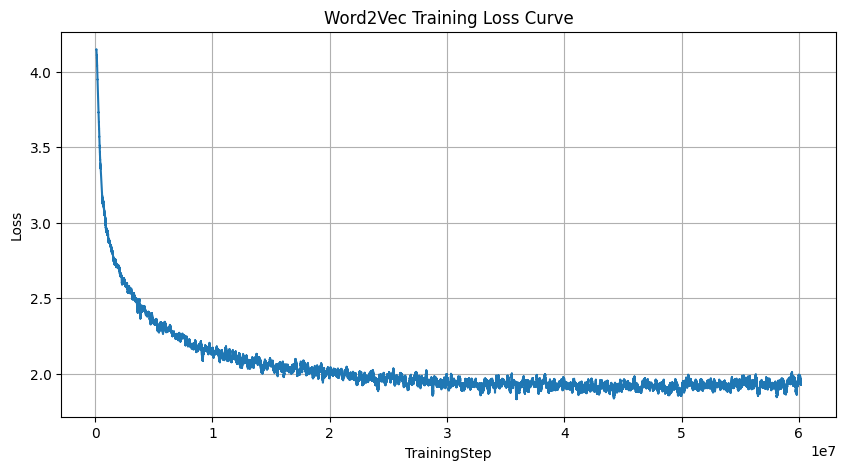

In [169]:
smoothed_losses = pd.Series(losses).rolling(window=LOSS_SMOOTH_WINDOW).mean()

plt.figure(figsize=(10, 5))

plt.plot(smoothed_losses)

plt.ylabel("Loss")
plt.xlabel("TrainingStep")
plt.title("Word2Vec Training Loss Curve")
plt.grid()
plt.show()

### Save Embedding Matrices

In [135]:
pickle.dump({"token_to_id": token_to_id,
             "embedding_matrix": embedding_matrix,
             "output_matrix": output_matrix }, open("data/word2vec_wikitext_103_1_epoch.pkl", "wb"))

# Test on Simple Examples to Test if Embeddings Capture Semantic Relations

In [173]:
def get_most_similar(embedding, embedding_matrix, id_to_token, top_k=10):
    matrix_norms = np.linalg.norm(embedding_matrix, axis=1)
    embedding_norm = np.linalg.norm(embedding)
    similarities = embedding_matrix @ embedding / (matrix_norms * embedding_norm + 1e-10)
    most_similar_ids = np.argsort(similarities)[-top_k:][::-1]
    most_similar_tokens = [id_to_token[idx] for idx in most_similar_ids]
    return most_similar_tokens

### Most Similar Words

In [175]:
token = "king"
print('Most similar words to "' + token + '":')
get_most_similar(embedding_matrix[token_to_id[token]], embedding_matrix, id_to_token)

Most similar words to "king":


['king',
 'prince',
 'throne',
 'emperor',
 'pope',
 'constantine',
 'edward',
 'henry',
 'tsar',
 'vi']

In [176]:
token = "queen"
print('Most similar words to "' + token + '":')
get_most_similar(embedding_matrix[token_to_id[token]], embedding_matrix, id_to_token)

Most similar words to "queen":


['queen',
 'princess',
 'elizabeth',
 'anne',
 'prince',
 'victoria',
 'mary',
 'isabella',
 'king',
 'duchess']

In [179]:
token = "programming"
print('Most similar words to "' + token + '":')
get_most_similar(embedding_matrix[token_to_id[token]], embedding_matrix, id_to_token)

Most similar words to "programming":


['programming',
 'audio',
 'animation',
 'computers',
 'electronic',
 'electronics',
 'interactive',
 'packaging',
 'computing',
 'multimedia']

### Word Arithmetic

In [ ]:
print('king - man + woman = ?')
get_most_similar(embedding_matrix[token_to_id["king"]] - 
                 embedding_matrix[token_to_id["man"]] + 
                 embedding_matrix[token_to_id["woman"]], 
                 embedding_matrix, id_to_token)

King - Man + Woman = ?


['king',
 'queen',
 'throne',
 'prince',
 'emperor',
 'elizabeth',
 'empress',
 'anne',
 'monarch',
 'matilda']

In [189]:
print('paris - france + germany = ?')
get_most_similar(embedding_matrix[token_to_id["paris"]] - 
                 embedding_matrix[token_to_id["france"]] + 
                 embedding_matrix[token_to_id["germany"]], 
                 embedding_matrix, id_to_token)

paris - france + germany = ?


['paris',
 'berlin',
 'vienna',
 'copenhagen',
 'moscow',
 'prague',
 'germany',
 'stockholm',
 'brussels',
 'hamburg']

In [190]:
print('tokyo - japan + china = ?')
get_most_similar(embedding_matrix[token_to_id["tokyo"]] - 
                 embedding_matrix[token_to_id["japan"]] + 
                 embedding_matrix[token_to_id["china"]], 
                 embedding_matrix, id_to_token)

tokyo - japan + china = ?


['geneva',
 'dublin',
 'newport',
 'berlin',
 'jakarta',
 'omaha',
 'istanbul',
 'perth',
 'greenwich',
 'taoyuan']

### As we can see, the trained Word2Vec embeddings are able to capture semantic relationships between tokens. The word arithmetic does not really work well, however this could be attributed to the small size of the WikiText-103 dataset.